1. Поиск и парсинг файлов в папке симуляции...
   Всего найдено конфигураций: 1862
   Используются все доступные конфигурации (без ограничений N_FILES)
Конфигурации распределены по выборкам стратифицированно:
  - Train симуляций: 1303
  - Val симуляций:   279
  - Test симуляций:  280
2. Извлечение глобальных признаков из файлов...

Размер тренировочной выборки (Train): 1303 точек
Размер валидационной выборки (Val): 279 точек
Размер тестовой выборки (Test): 280 точек

=== МЕТРИКИ НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ (VAL) ===
R² h: 0.9065 | MAE h: 0.0316
R² p: 0.9727 | MAE p: 0.4188

=== МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ (TEST) ===
R² h: 0.9002 | MAE h: 0.0306
R² p: 0.9690 | MAE p: 0.4092

Важность глобальных признаков:
diffusion_coeff       0.792431
psi_3                 0.058507
psi_5                 0.038914
voronoi_peak_ratio    0.028509
num_layers            0.022846
psi_6                 0.021860
psi_4                 0.020453
snake_length_avg      0.010279
density               0.003889
triplet_ra

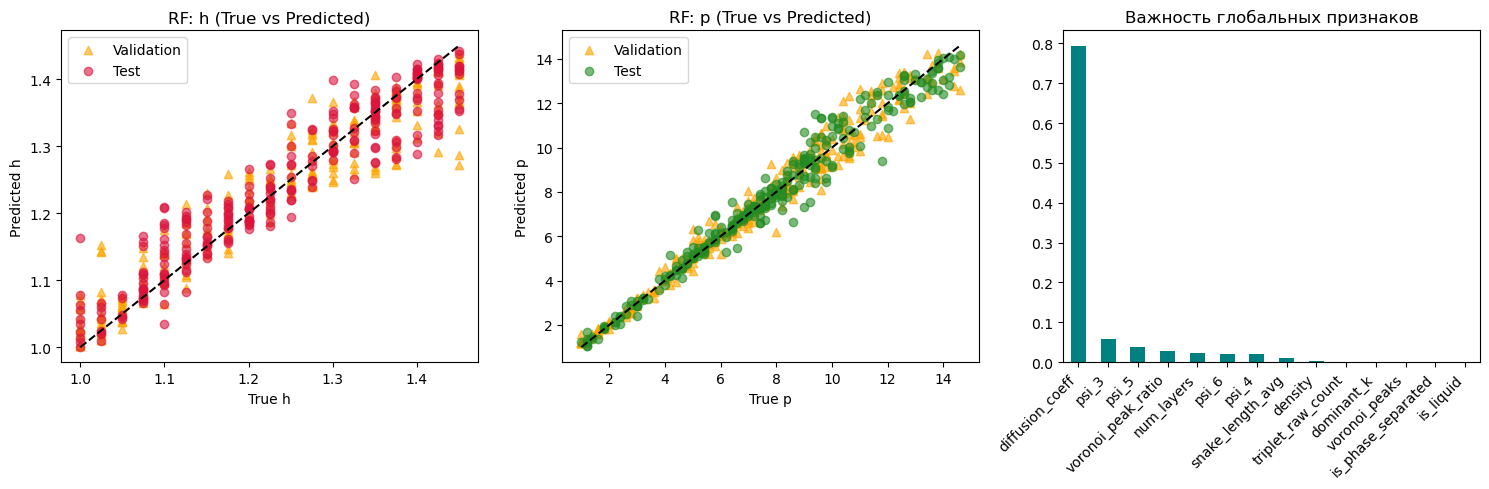

In [5]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 1. НАСТРОЙКИ ПУТЕЙ И СЕТКИ СИМУЛЯЦИИ
# ==========================================
SIM_DIR = r"C:\Users\Asus\Downloads\simulation_data"  # Укажите путь к папке с вашими .txt файлами

# Установите None, чтобы убрать лимит и использовать ВСЕ доступные файлы симуляций
N_FILES = None  

RANDOM_SEED = 42
TEMP = 1.0

# Сетки значений h и mu (p) для поиска файлов (соответствует вашему коду)
h_values = np.arange(1.0, 1.475, 0.025)
mu_values = np.arange(1.0, 10.6, 0.2)

# Порог диффузии
SIM_MSD_THRESHOLD = 0.05

# ==========================================

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# ==========================================
# 2. СТРУКТУРА ДАННЫХ ИЗ PHASE_MAP
# ==========================================
@dataclass
class SimulationPoint:
    h: float
    mu: float
    rho: float
    temp: float

    # Физические свойства
    num_layers: int = 0
    diffusion_coeff: float = 0.0
    mobility_phase: str = "Unknown"
    psi_values: dict = field(default_factory=dict)
    dominant_k: int = 0

    # Вороной / Флуктуации плотности
    voronoi_peaks: int = 0
    voronoi_peak_pos: list = field(default_factory=list)
    is_phase_separated: bool = False

    # Змейки и триплеты
    triplet_raw_count: int = 0
    snake_length_avg: float = 0.0


# ==========================================
# 3. ФУНКЦИИ-АНАЛИЗАТОРЫ ИЗ PHASE_MAP
# ==========================================
def parse_global_filename(filepath):
    base = os.path.basename(filepath)
    base = os.path.splitext(base)[0]
    parts = base.split("_")
    try:
        rho = float(parts[1])
        h = float(parts[2])
        temp = float(parts[3])
        mu = float(parts[4])
        return rho, h, temp, mu
    except Exception:
        return None, None, None, None


def get_all_sim_points(data_dir):
    points_dict = {}
    pattern = os.path.join(data_dir, "Sigma2t_*.txt")
    files = glob.glob(pattern)
    for f in files:
        rho, h, temp, mu = parse_global_filename(f)
        if rho is not None:
            points_dict[(rho, h, temp, mu)] = SimulationPoint(h=h, mu=mu, rho=rho, temp=temp)
    return points_dict


def analyze_z_coord(points_dict, data_dir):
    for pt in points_dict.values():
        filepath = os.path.join(data_dir, f"Z_coord_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
        try:
            data = np.loadtxt(filepath)
            if data.size > 0 and len(data.shape) == 2:
                counts = data[:, 1]
                if max(counts) > 0: counts = counts / max(counts)
                peaks, _ = find_peaks(np.concatenate(([0], counts, [0])), prominence=0.02)
                pt.num_layers = len(peaks)
        except Exception:
            pt.num_layers = 0


def analyze_msd(points_dict, data_dir, threshold):
    for pt in points_dict.values():
        filepath = os.path.join(data_dir, f"Sigma2t_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
        try:
            msd = np.loadtxt(filepath)
            if msd.size >= 10:
                time = np.arange(len(msd))
                half_idx = len(msd[:-1]) // 2
                k, b = np.polyfit(time[half_idx:], msd[half_idx:], 1)
                pt.diffusion_coeff = k / 4.0
                pt.mobility_phase = 'Liquid' if pt.diffusion_coeff >= threshold else 'Crystal'
        except Exception:
            pt.diffusion_coeff = 0.0
            pt.mobility_phase = 'Unknown'


def analyze_orientational_order(points_dict, data_dir, threshold=0.4):
    for pt in points_dict.values():
        for k in [3, 4, 5, 6]:
            filepath = os.path.join(data_dir, f"AvPsi{k}_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
            try:
                data = np.loadtxt(filepath)
                val = float(np.mean(data)) if data.size > 1 else float(data)
                pt.psi_values[k] = val
            except Exception:
                pt.psi_values[k] = 0.0

        if not pt.psi_values: continue
        max_k = max(pt.psi_values, key=pt.psi_values.get)
        pt.dominant_k = max_k if pt.psi_values[max_k] >= threshold else 0


def analyze_voronoi_fluctuations(points_dict, data_dir, min_prominence=0.05, min_distance_ratio=2.0):
    for pt in points_dict.values():
        filepath = os.path.join(data_dir, f"S_vor(RDF)__{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
        try:
            data = np.loadtxt(filepath)
            x = data[:, 0] if data.ndim == 2 else np.arange(len(data))
            y = data[:, 1] if data.ndim == 2 else data
            if max(y) > 0: y = y / max(y)

            peaks, _ = find_peaks(y, prominence=min_prominence)
            pt.voronoi_peaks = len(peaks)
            pt.voronoi_peak_pos = x[peaks].tolist()
            pt.is_phase_separated = False

            if len(pt.voronoi_peak_pos) >= 2:
                small_p, big_p = min(pt.voronoi_peak_pos), max(pt.voronoi_peak_pos)
                if small_p > 0 and (big_p / small_p) >= min_distance_ratio:
                    pt.is_phase_separated = True
        except Exception:
            pt.is_phase_separated = False


def analyze_triplets(points_dict, data_dir):
    for pt in points_dict.values():
        filepath = os.path.join(data_dir, f"Triplets_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
        if os.path.exists(filepath):
            try:
                data = np.atleast_1d(np.loadtxt(filepath))
                if data.size == 0 or (len(data) == 1 and data[0] == 0):
                    pt.triplet_raw_count = 0
                else:
                    pt.triplet_raw_count = len(data)
            except Exception:
                pt.triplet_raw_count = 0


def analyze_snake_length(points_dict, data_dir):
    for pt in points_dict.values():
        filepath = os.path.join(data_dir, f"Av_Length_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
        try:
            pt.snake_length_avg = float(np.loadtxt(filepath))
        except Exception:
            pt.snake_length_avg = 0.0


# ==========================================
# 4. СБОР ГЛОБАЛЬНОГО ДАТАСЕТА
# ==========================================
print("1. Поиск и парсинг файлов в папке симуляции...")
all_sim_points = get_all_sim_points(SIM_DIR)

if not all_sim_points:
    raise ValueError(f"Не найдено файлов симуляций в папке: {SIM_DIR}")

print(f"   Всего найдено конфигураций: {len(all_sim_points)}")

# Сбор параметров для стратификации
keys = list(all_sim_points.keys())
densities_str = [f"{k[0]:.2f}" for k in keys]

# -------------------------------------------------------------
# ИЗМЕНЕНО: СТРАТИФИЦИРОВАННЫЙ ОТБОР (ТОЛЬКО ЕСЛИ N_FILES ЗАДАН)
# -------------------------------------------------------------
if N_FILES is not None and len(keys) > N_FILES:
    selected_keys, _, _, _ = train_test_split(
        keys, densities_str,
        train_size=N_FILES,
        stratify=densities_str,
        random_state=RANDOM_SEED
    )
    print(f"   Применено ограничение N_FILES={N_FILES}")
else:
    selected_keys = keys
    print("   Используются все доступные конфигурации (без ограничений N_FILES)")

# Сбор строковых плотностей для выбранного набора
selected_densities = [f"{k[0]:.2f}" for k in selected_keys]

# -------------------------------------------------------------
# СТРАТИФИЦИРОВАННОЕ РАЗДЕЛЕНИЕ НА TRAIN, VAL, TEST (70/15/15)
# -------------------------------------------------------------
train_keys, temp_keys, _, temp_dens = train_test_split(
    selected_keys, selected_densities,
    test_size=0.3,
    stratify=selected_densities,
    random_state=RANDOM_SEED
)

val_keys, test_keys = train_test_split(
    temp_keys,
    test_size=0.5,
    stratify=temp_dens,
    random_state=RANDOM_SEED
)

print(f"Конфигурации распределены по выборкам стратифицированно:")
print(f"  - Train симуляций: {len(train_keys)}")
print(f"  - Val симуляций:   {len(val_keys)}")
print(f"  - Test симуляций:  {len(test_keys)}")

train_keys_set = set(train_keys)
val_keys_set = set(val_keys)

# Создаем подсловарь только для выбранных точек
selected_sim_dict = {k: all_sim_points[k] for k in selected_keys}

print("2. Извлечение глобальных признаков из файлов...")
analyze_z_coord(selected_sim_dict, SIM_DIR)
analyze_msd(selected_sim_dict, SIM_DIR, SIM_MSD_THRESHOLD)
analyze_orientational_order(selected_sim_dict, SIM_DIR)
analyze_voronoi_fluctuations(selected_sim_dict, SIM_DIR)
analyze_triplets(selected_sim_dict, SIM_DIR)
analyze_snake_length(selected_sim_dict, SIM_DIR)

# Преобразуем извлеченные объекты в DataFrame
data_rows = []
for key, pt in selected_sim_dict.items():
    peak_ratio = 1.0
    if len(pt.voronoi_peak_pos) >= 2 and min(pt.voronoi_peak_pos) > 0:
        peak_ratio = max(pt.voronoi_peak_pos) / min(pt.voronoi_peak_pos)

    # Определяем маркер выборки
    if key in train_keys_set:
        split_name = "train"
    elif key in val_keys_set:
        split_name = "val"
    else:
        split_name = "test"

    data_rows.append({
        "density": pt.rho,
        "h": pt.h,
        "p": pt.mu,
        
        # Глобальные признаки
        "num_layers": pt.num_layers,
        "diffusion_coeff": pt.diffusion_coeff,
        "is_liquid": 1.0 if pt.mobility_phase == 'Liquid' else 0.0,
        "psi_3": pt.psi_values.get(3, 0.0),
        "psi_4": pt.psi_values.get(4, 0.0),
        "psi_5": pt.psi_values.get(5, 0.0),
        "psi_6": pt.psi_values.get(6, 0.0),
        "dominant_k": pt.dominant_k,
        "voronoi_peaks": pt.voronoi_peaks,
        "is_phase_separated": 1.0 if pt.is_phase_separated else 0.0,
        "voronoi_peak_ratio": peak_ratio,
        "triplet_raw_count": pt.triplet_raw_count,
        "snake_length_avg": pt.snake_length_avg,
        "split": split_name
    })

df = pd.DataFrame(data_rows)


# ==========================================
# 5. ОБУЧЕНИЕ МОДЕЛИ RANDOM FOREST
# ==========================================
train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "val"]
test_df = df[df["split"] == "test"]

target_cols = ["h", "p"]
exclude_cols = ["split"] + target_cols

X_train = train_df.drop(columns=exclude_cols)
y_train = train_df[target_cols]

X_val = val_df.drop(columns=exclude_cols)
y_val = val_df[target_cols]

X_test = test_df.drop(columns=exclude_cols)
y_test = test_df[target_cols]

print(f"\nРазмер тренировочной выборки (Train): {X_train.shape[0]} точек")
print(f"Размер валидационной выборки (Val): {X_val.shape[0]} точек")
print(f"Размер тестовой выборки (Test): {X_test.shape[0]} точек")

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Делаем предсказания для Validation и Test отдельно
preds_val = model.predict(X_val)
preds_test = model.predict(X_test)


# ==========================================
# 6. ВЫВОД МЕТРИК И ВАЖНОСТИ ПРИЗНАКОВ
# ==========================================
r2_h_val = r2_score(y_val["h"], preds_val[:, 0])
r2_p_val = r2_score(y_val["p"], preds_val[:, 1])
mae_h_val = mean_absolute_error(y_val["h"], preds_val[:, 0])
mae_p_val = mean_absolute_error(y_val["p"], preds_val[:, 1])

r2_h_test = r2_score(y_test["h"], preds_test[:, 0])
r2_p_test = r2_score(y_test["p"], preds_test[:, 1])
mae_h_test = mean_absolute_error(y_test["h"], preds_test[:, 0])
mae_p_test = mean_absolute_error(y_test["p"], preds_test[:, 1])

print("\n=== МЕТРИКИ НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ (VAL) ===")
print(f"R² h: {r2_h_val:.4f} | MAE h: {mae_h_val:.4f}")
print(f"R² p: {r2_p_val:.4f} | MAE p: {mae_p_val:.4f}")

print("\n=== МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ (TEST) ===")
print(f"R² h: {r2_h_test:.4f} | MAE h: {mae_h_test:.4f}")
print(f"R² p: {r2_p_test:.4f} | MAE p: {mae_p_test:.4f}")

# Важность признаков
importance = pd.Series(model.feature_importances_, index=X_train.columns)
print("\nВажность глобальных признаков:")
print(importance.sort_values(ascending=False))


# ==========================================
# 7. ОТРИСОВКА TRUE VS PREDICTED И ВАЖНОСТИ
# ==========================================
plt.figure(figsize=(15, 5))

# График для h
plt.subplot(1, 3, 1)
plt.scatter(y_val["h"], preds_val[:, 0], color="orange", alpha=0.6, marker="^", label="Validation")
plt.scatter(y_test["h"], preds_test[:, 0], color="crimson", alpha=0.6, marker="o", label="Test")
min_v = min(y_test["h"].min(), preds_test[:, 0].min(), y_val["h"].min())
max_v = max(y_test["h"].max(), preds_test[:, 0].max(), y_val["h"].max())
plt.plot([min_v, max_v], [min_v, max_v], "k--")
plt.title("RF: h (True vs Predicted)")
plt.xlabel("True h")
plt.ylabel("Predicted h")
plt.legend()

# График для p (mu)
plt.subplot(1, 3, 2)
plt.scatter(y_val["p"], preds_val[:, 1], color="orange", alpha=0.6, marker="^", label="Validation")
plt.scatter(y_test["p"], preds_test[:, 1], color="forestgreen", alpha=0.6, marker="o", label="Test")
min_v = min(y_test["p"].min(), preds_test[:, 1].min(), y_val["p"].min())
max_v = max(y_test["p"].max(), preds_test[:, 1].max(), y_val["p"].max())
plt.plot([min_v, max_v], [min_v, max_v], "k--")
plt.title("RF: p (True vs Predicted)")
plt.xlabel("True p")
plt.ylabel("Predicted p")
plt.legend()

# Важность признаков
plt.subplot(1, 3, 3)
importance.sort_values(ascending=False).plot.bar(color="teal")
plt.title("Важность глобальных признаков")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


=== VAL ===
R2 h: 0.5256118067260354
R2 p: 0.8813958983575394
MAE h: 0.061541708367391666
MAE p: 0.7754822317016915

=== TEST ===
R2 h: 0.6056911884188866
R2 p: 0.933552379890566
MAE h: 0.0604090977785285
MAE p: 0.6262940033233815


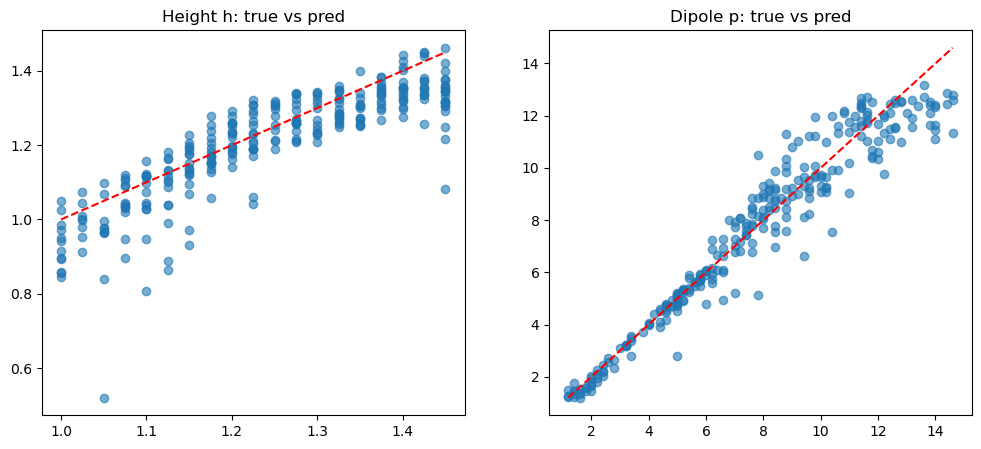

In [11]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from scipy.signal import find_peaks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error


# =========================
# CONFIG
# =========================
SIM_DIR = r"C:\Users\Asus\Downloads\simulation_data" 
RANDOM_SEED = 42
SIM_MSD_THRESHOLD = 0.05

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# =========================
# DATA STRUCTURE
# =========================
@dataclass
class SimulationPoint:
    h: float
    mu: float
    rho: float
    temp: float

    num_layers: int = 0
    diffusion_coeff: float = 0.0
    mobility_phase: str = "Unknown"
    psi_values: dict = field(default_factory=dict)
    dominant_k: int = 0


# =========================
# FILE PARSING
# =========================
def parse_global_filename(filepath):
    base = os.path.basename(filepath)
    base = os.path.splitext(base)[0]
    parts = base.split("_")
    try:
        rho = float(parts[1])
        h = float(parts[2])
        temp = float(parts[3])
        mu = float(parts[4])
        return rho, h, temp, mu
    except:
        return None, None, None, None


def get_all_sim_points(data_dir):
    points_dict = {}
    pattern = os.path.join(data_dir, "Sigma2t_*.txt")
    files = glob.glob(pattern)

    for f in files:
        rho, h, temp, mu = parse_global_filename(f)
        if rho is not None:
            points_dict[(rho, h, temp, mu)] = SimulationPoint(
                h=h, mu=mu, rho=rho, temp=temp
            )

    return points_dict


# =========================
# FEATURE ENGINEERING
# =========================
def analyze_z_coord(points_dict, data_dir):
    for pt in points_dict.values():
        filepath = os.path.join(data_dir, f"Z_coord_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
        try:
            data = np.loadtxt(filepath)
            if data.size > 0 and len(data.shape) == 2:
                counts = data[:, 1]
                if np.max(counts) > 0:
                    counts = counts / np.max(counts)
                peaks, _ = find_peaks(np.concatenate(([0], counts, [0])), prominence=0.02)
                pt.num_layers = len(peaks)
        except:
            pt.num_layers = 0


def analyze_msd(points_dict, data_dir, threshold):
    for pt in points_dict.values():
        filepath = os.path.join(data_dir, f"Sigma2t_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
        try:
            msd = np.loadtxt(filepath)
            if msd.size >= 10:
                t = np.arange(len(msd))
                half = len(msd) // 2
                k, _ = np.polyfit(t[half:], msd[half:], 1)
                pt.diffusion_coeff = k / 4.0
                pt.mobility_phase = "Liquid" if pt.diffusion_coeff >= threshold else "Crystal"
        except:
            pt.diffusion_coeff = 0.0
            pt.mobility_phase = "Unknown"


def analyze_orientational_order(points_dict, data_dir):
    for pt in points_dict.values():
        pt.psi_values = {}

        for k in [3, 4, 5, 6]:
            filepath = os.path.join(data_dir, f"AvPsi{k}_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
            try:
                data = np.loadtxt(filepath)
                pt.psi_values[k] = float(np.mean(data))
            except:
                pt.psi_values[k] = 0.0

        pt.dominant_k = max(pt.psi_values, key=pt.psi_values.get)


# =========================
# BUILD DATASET
# =========================
all_sim_points = get_all_sim_points(SIM_DIR)

analyze_z_coord(all_sim_points, SIM_DIR)
analyze_msd(all_sim_points, SIM_DIR, SIM_MSD_THRESHOLD)
analyze_orientational_order(all_sim_points, SIM_DIR)

rows = []
for pt in all_sim_points.values():
    rows.append({
        "rho": pt.rho,
        "h": pt.h,
        "p": pt.mu,
        "num_layers": pt.num_layers,
        "diffusion_coeff": pt.diffusion_coeff,
        "is_liquid": 1.0 if pt.mobility_phase == "Liquid" else 0.0,
        "psi_3": pt.psi_values.get(3, 0.0),
        "psi_4": pt.psi_values.get(4, 0.0),
        "psi_5": pt.psi_values.get(5, 0.0),
        "psi_6": pt.psi_values.get(6, 0.0),
        "dominant_k": pt.dominant_k,
    })

df = pd.DataFrame(rows)


# =========================
# SPLIT
# =========================
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=RANDOM_SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=RANDOM_SEED)

X_train = train_df.drop(columns=["h", "p"])
y_train = train_df[["h", "p"]]

X_val = val_df.drop(columns=["h", "p"])
y_val = val_df[["h", "p"]]

X_test = test_df.drop(columns=["h", "p"])
y_test = test_df[["h", "p"]]


# =========================
# SCALING (IMPORTANT)
# =========================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# =========================
# KERNEL RIDGE REGRESSION
# =========================
model = MultiOutputRegressor(
    KernelRidge(kernel="rbf", alpha=1.0, gamma=0.5)
)

model.fit(X_train, y_train)

pred_val = model.predict(X_val)
pred_test = model.predict(X_test)


# =========================
# METRICS
# =========================
def report(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print("R2 h:", r2_score(y_true["h"], y_pred[:,0]))
    print("R2 p:", r2_score(y_true["p"], y_pred[:,1]))
    print("MAE h:", mean_absolute_error(y_true["h"], y_pred[:,0]))
    print("MAE p:", mean_absolute_error(y_true["p"], y_pred[:,1]))

report(y_val, pred_val, "VAL")
report(y_test, pred_test, "TEST")


# =========================
# PLOTS
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test["h"], pred_test[:,0], alpha=0.6)
plt.plot([y_test["h"].min(), y_test["h"].max()],
         [y_test["h"].min(), y_test["h"].max()], 'r--')
plt.title("Height h: true vs pred")

plt.subplot(1,2,2)
plt.scatter(y_test["p"], pred_test[:,1], alpha=0.6)
plt.plot([y_test["p"].min(), y_test["p"].max()],
         [y_test["p"].min(), y_test["p"].max()], 'r--')
plt.title("Dipole p: true vs pred")

plt.show()


=== FINAL DISTRIBUTION ===

TRAIN
rho
0.7    651
0.8    651
Name: count, dtype: int64

VAL
rho
0.7    140
0.8    140
Name: count, dtype: int64

TEST
rho
0.7    140
0.8    140
Name: count, dtype: int64

=== VAL ===
R2 h: 0.5256118067260354
R2 p: 0.8813958983575393
MAE h: 0.0615417083673917
MAE p: 0.7754822317016913

=== TEST ===
R2 h: 0.6056911884188871
R2 p: 0.9335523798905659
MAE h: 0.06040909777852841
MAE p: 0.6262940033233816


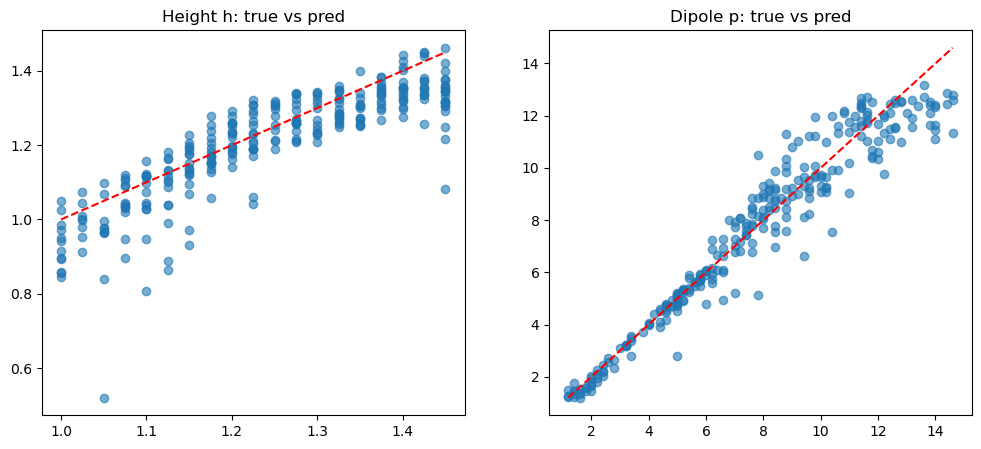

In [13]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from scipy.signal import find_peaks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error


# =========================
# CONFIG
# =========================
SIM_DIR = r"C:\Users\Asus\Downloads\simulation_data" 
RANDOM_SEED = 42
SIM_MSD_THRESHOLD = 0.05

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# =========================
# DATA STRUCTURE
# =========================
@dataclass
class SimulationPoint:
    h: float
    mu: float
    rho: float
    temp: float

    num_layers: int = 0
    diffusion_coeff: float = 0.0
    mobility_phase: str = "Unknown"
    psi_values: dict = field(default_factory=dict)
    dominant_k: int = 0


# =========================
# FILE PARSING
# =========================
def parse_global_filename(filepath):
    base = os.path.basename(filepath)
    base = os.path.splitext(base)[0]
    parts = base.split("_")
    try:
        rho = float(parts[1])
        h = float(parts[2])
        temp = float(parts[3])
        mu = float(parts[4])
        return rho, h, temp, mu
    except:
        return None, None, None, None


def get_all_sim_points(data_dir):
    points_dict = {}
    pattern = os.path.join(data_dir, "Sigma2t_*.txt")
    files = glob.glob(pattern)

    for f in files:
        rho, h, temp, mu = parse_global_filename(f)
        if rho is not None:
            points_dict[(rho, h, temp, mu)] = SimulationPoint(
                h=h, mu=mu, rho=rho, temp=temp
            )

    return points_dict


# =========================
# FEATURE ENGINEERING
# =========================
def analyze_z_coord(points_dict, data_dir):
    for pt in points_dict.values():
        filepath = os.path.join(data_dir, f"Z_coord_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
        try:
            data = np.loadtxt(filepath)
            if data.size > 0 and len(data.shape) == 2:
                counts = data[:, 1]
                if np.max(counts) > 0:
                    counts = counts / np.max(counts)
                peaks, _ = find_peaks(np.concatenate(([0], counts, [0])), prominence=0.02)
                pt.num_layers = len(peaks)
        except:
            pt.num_layers = 0


def analyze_msd(points_dict, data_dir, threshold):
    for pt in points_dict.values():
        filepath = os.path.join(data_dir, f"Sigma2t_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
        try:
            msd = np.loadtxt(filepath)
            if msd.size >= 10:
                t = np.arange(len(msd))
                half = len(msd) // 2
                k, _ = np.polyfit(t[half:], msd[half:], 1)
                pt.diffusion_coeff = k / 4.0
                pt.mobility_phase = "Liquid" if pt.diffusion_coeff >= threshold else "Crystal"
        except:
            pt.diffusion_coeff = 0.0
            pt.mobility_phase = "Unknown"


def analyze_orientational_order(points_dict, data_dir):
    for pt in points_dict.values():
        pt.psi_values = {}

        for k in [3, 4, 5, 6]:
            filepath = os.path.join(data_dir, f"AvPsi{k}_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
            try:
                data = np.loadtxt(filepath)
                pt.psi_values[k] = float(np.mean(data))
            except:
                pt.psi_values[k] = 0.0

        pt.dominant_k = max(pt.psi_values, key=pt.psi_values.get)


# =========================
# BUILD DATASET
# =========================
all_sim_points = get_all_sim_points(SIM_DIR)

analyze_z_coord(all_sim_points, SIM_DIR)
analyze_msd(all_sim_points, SIM_DIR, SIM_MSD_THRESHOLD)
analyze_orientational_order(all_sim_points, SIM_DIR)

rows = []
for pt in all_sim_points.values():
    rows.append({
        "rho": pt.rho,
        "h": pt.h,
        "p": pt.mu,
        "num_layers": pt.num_layers,
        "diffusion_coeff": pt.diffusion_coeff,
        "is_liquid": 1.0 if pt.mobility_phase == "Liquid" else 0.0,
        "psi_3": pt.psi_values.get(3, 0.0),
        "psi_4": pt.psi_values.get(4, 0.0),
        "psi_5": pt.psi_values.get(5, 0.0),
        "psi_6": pt.psi_values.get(6, 0.0),
        "dominant_k": pt.dominant_k,
    })

df = pd.DataFrame(rows)


# =========================
# SPLIT
# =========================
from sklearn.model_selection import train_test_split

train_parts = []
val_parts = []
test_parts = []

# --------------------------
# split внутри каждой rho
# --------------------------
for rho in df["rho"].unique():
    sub = df[df["rho"] == rho]

    # 70% train, 30% temp
    train_sub, temp_sub = train_test_split(
        sub,
        test_size=0.3,
        random_state=42
    )

    # 50% of temp -> val, 50% -> test
    val_sub, test_sub = train_test_split(
        temp_sub,
        test_size=0.5,
        random_state=42
    )

    train_parts.append(train_sub)
    val_parts.append(val_sub)
    test_parts.append(test_sub)

# --------------------------
# merge back
# --------------------------
train_df = pd.concat(train_parts).reset_index(drop=True)
val_df   = pd.concat(val_parts).reset_index(drop=True)
test_df  = pd.concat(test_parts).reset_index(drop=True)

# --------------------------
# check distribution
# --------------------------
print("\n=== FINAL DISTRIBUTION ===")

for name, split in [("TRAIN", train_df), ("VAL", val_df), ("TEST", test_df)]:
    print(f"\n{name}")
    print(split["rho"].value_counts().sort_index())

# =========================
# SCALING (IMPORTANT)
# =========================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# =========================
# KERNEL RIDGE REGRESSION
# =========================
model = MultiOutputRegressor(
    KernelRidge(kernel="rbf", alpha=1.0, gamma=0.5)
)

model.fit(X_train, y_train)

pred_val = model.predict(X_val)
pred_test = model.predict(X_test)


# =========================
# METRICS
# =========================
def report(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print("R2 h:", r2_score(y_true["h"], y_pred[:,0]))
    print("R2 p:", r2_score(y_true["p"], y_pred[:,1]))
    print("MAE h:", mean_absolute_error(y_true["h"], y_pred[:,0]))
    print("MAE p:", mean_absolute_error(y_true["p"], y_pred[:,1]))

report(y_val, pred_val, "VAL")
report(y_test, pred_test, "TEST")


# =========================
# PLOTS
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test["h"], pred_test[:,0], alpha=0.6)
plt.plot([y_test["h"].min(), y_test["h"].max()],
         [y_test["h"].min(), y_test["h"].max()], 'r--')
plt.title("Height h: true vs pred")

plt.subplot(1,2,2)
plt.scatter(y_test["p"], pred_test[:,1], alpha=0.6)
plt.plot([y_test["p"].min(), y_test["p"].max()],
         [y_test["p"].min(), y_test["p"].max()], 'r--')
plt.title("Dipole p: true vs pred")

plt.show()

c:\Users\Asus\anaconda\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Asus\anaconda\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Asus\anaconda\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Asus\anaconda\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Asus\anaconda\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Asus\anacon


================ RBF ================
Best per kernel: {'mae': 0.3221639214421649, 'alpha': 0.0001, 'gamma': 0.2}


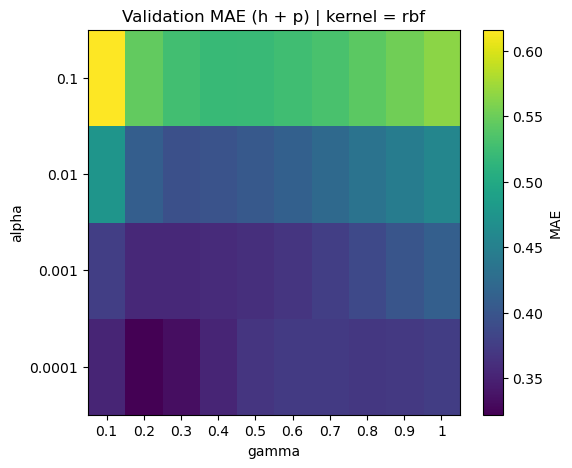


================ POLY ================
Best per kernel: {'mae': 0.46485763919947365, 'alpha': 0.1, 'gamma': 0.5}


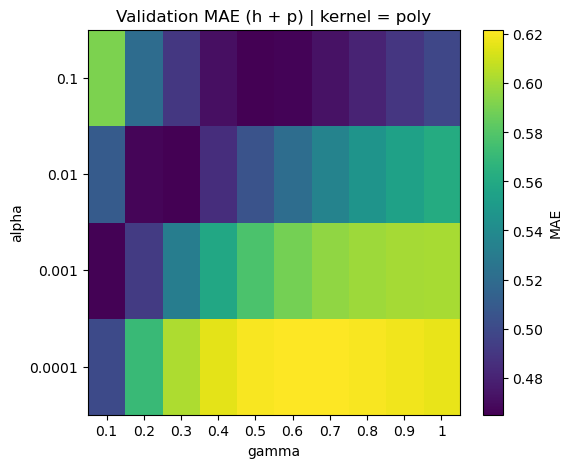


================ SIGMOID ================
Best per kernel: {'mae': 1.330365047541854, 'alpha': 0.1, 'gamma': 0.4}


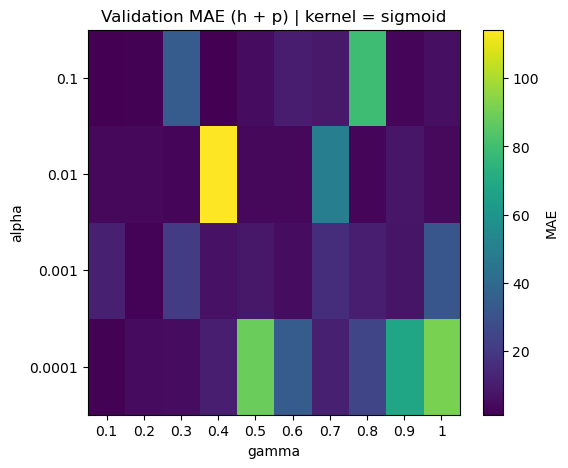


================ GLOBAL BEST ================
{'mae': 0.3221639214421649, 'kernel': 'rbf', 'alpha': 0.0001, 'gamma': 0.2}

================ TEST RESULTS ================
Kernel: rbf
Alpha: 0.0001
Gamma: 0.2

--- MAE ---
MAE h: 0.027329522968569345
MAE p: 0.31231885174456037
MAE total: 0.3396483747131297

--- R2 ---
R2 h: 0.9041160323983553
R2 p: 0.9709686306256304


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.kernel_ridge import KernelRidge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

# =========================
# PARAM GRID
# =========================
alphas = [0.0001, 0.001, 0.01, 0.1]
gammas = [0.1, 0.2, 0.3, 0.4, 0.5,  0.6, 0.7, 0.8, 0.9, 1]
kernels = ["rbf", "poly", "sigmoid"]

# =========================
# STORAGE
# =========================
results = {}

best_global = {
    "mae": np.inf,
    "kernel": None,
    "alpha": None,
    "gamma": None
}

best_per_kernel = {}

# =========================
# GRID SEARCH (VALIDATION)
# =========================
for kernel in kernels:

    results[kernel] = np.zeros((len(alphas), len(gammas)))

    best_kernel = {
        "mae": np.inf,
        "alpha": None,
        "gamma": None
    }

    for i, alpha in enumerate(alphas):
        for j, gamma in enumerate(gammas):

            model = MultiOutputRegressor(
                KernelRidge(kernel=kernel, alpha=alpha, gamma=gamma)
            )

            model.fit(X_train, y_train)
            pred = model.predict(X_val)

            mae_h = mean_absolute_error(y_val["h"], pred[:, 0])
            mae_p = mean_absolute_error(y_val["p"], pred[:, 1])
            mae_total = mae_h + mae_p

            results[kernel][i, j] = mae_total

            # best per kernel
            if mae_total < best_kernel["mae"]:
                best_kernel.update({
                    "mae": mae_total,
                    "alpha": alpha,
                    "gamma": gamma
                })

            # global best
            if mae_total < best_global["mae"]:
                best_global.update({
                    "mae": mae_total,
                    "kernel": kernel,
                    "alpha": alpha,
                    "gamma": gamma
                })

    best_per_kernel[kernel] = best_kernel

# =========================
# HEATMAPS + BEST PER KERNEL
# =========================
for kernel in kernels:

    print(f"\n================ {kernel.upper()} ================")
    print("Best per kernel:", best_per_kernel[kernel])

    plt.figure(figsize=(6,5))
    plt.title(f"Validation MAE (h + p) | kernel = {kernel}")

    plt.imshow(results[kernel], origin="lower", aspect="auto", cmap="viridis")
    plt.colorbar(label="MAE")

    plt.xticks(range(len(gammas)), gammas)
    plt.yticks(range(len(alphas)), alphas)

    plt.xlabel("gamma")
    plt.ylabel("alpha")

    plt.show()

# =========================
# GLOBAL BEST
# =========================
print("\n================ GLOBAL BEST ================")
print(best_global)

# =========================
# FINAL MODEL TRAINING
# =========================
best_model = MultiOutputRegressor(
    KernelRidge(
        kernel=best_global["kernel"],
        alpha=best_global["alpha"],
        gamma=best_global["gamma"]
    )
)

best_model.fit(X_train, y_train)
test_pred = best_model.predict(X_test)

# =========================
# TEST METRICS
# =========================
from sklearn.metrics import r2_score

# =========================
# TEST METRICS
# =========================
mae_h_test = mean_absolute_error(y_test["h"], test_pred[:, 0])
mae_p_test = mean_absolute_error(y_test["p"], test_pred[:, 1])
mae_total_test = mae_h_test + mae_p_test

r2_h_test = r2_score(y_test["h"], test_pred[:, 0])
r2_p_test = r2_score(y_test["p"], test_pred[:, 1])

print("\n================ TEST RESULTS ================")
print("Kernel:", best_global["kernel"])
print("Alpha:", best_global["alpha"])
print("Gamma:", best_global["gamma"])

print("\n--- MAE ---")
print("MAE h:", mae_h_test)
print("MAE p:", mae_p_test)
print("MAE total:", mae_total_test)

print("\n--- R2 ---")
print("R2 h:", r2_h_test)
print("R2 p:", r2_p_test)

c:\Users\Asus\anaconda\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Asus\anaconda\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Asus\anaconda\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Asus\anaconda\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Asus\anaconda\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Asus\anacon


=== Ядро: rbf ===
Лучшие параметры: {'mae': 0.3221639214468669, 'alpha': 0.0001, 'gamma': 0.2}


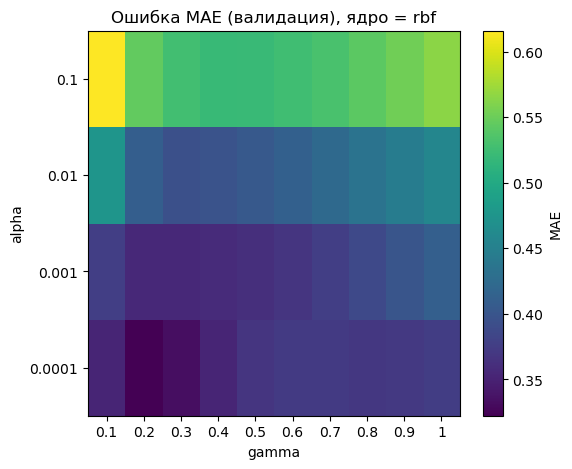


=== Ядро: poly ===
Лучшие параметры: {'mae': 0.46485763919517387, 'alpha': 0.1, 'gamma': 0.5}


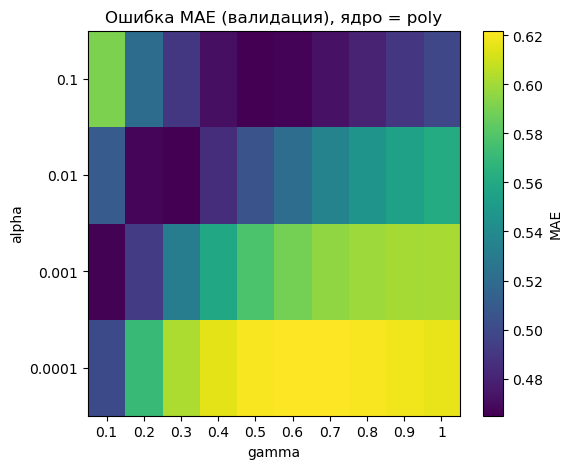


=== Ядро: sigmoid ===
Лучшие параметры: {'mae': 1.3303650475419428, 'alpha': 0.1, 'gamma': 0.4}


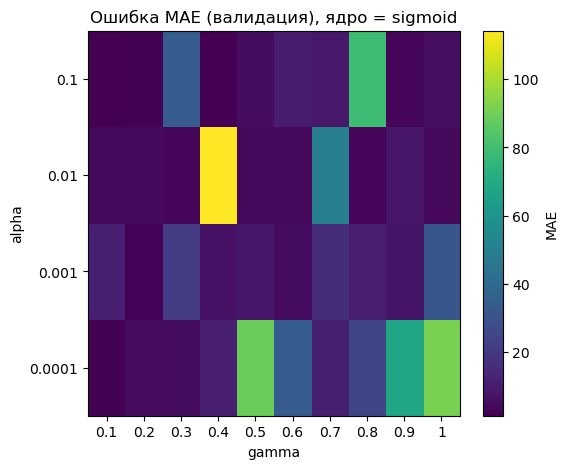


=== ЛУЧШАЯ МОДЕЛЬ ===
{'mae': 0.3221639214468669, 'kernel': 'rbf', 'alpha': 0.0001, 'gamma': 0.2}

=== ТЕСТОВЫЕ РЕЗУЛЬТАТЫ ===
Ядро: rbf
alpha: 0.0001
gamma: 0.2

MAE h: 0.02732952296802016
MAE p: 0.3123188517460044
MAE total: 0.33964837471402454

R2 h: 0.9041160323994857
R2 p: 0.9709686306261409


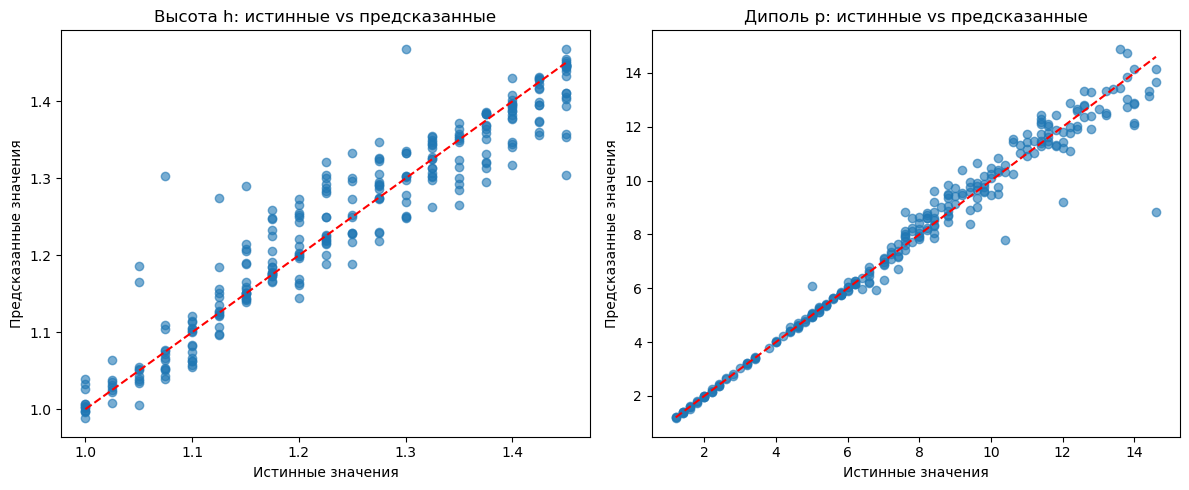

In [20]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from scipy.signal import find_peaks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error


# =========================
# CONFIG
# =========================
SIM_DIR = r"C:\Users\Asus\Downloads\simulation_data"
RANDOM_SEED = 42
SIM_MSD_THRESHOLD = 0.05

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# =========================
# DATA STRUCTURE
# =========================
@dataclass
class SimulationPoint:
    h: float
    mu: float
    rho: float
    temp: float

    num_layers: int = 0
    diffusion_coeff: float = 0.0
    mobility_phase: str = "Unknown"
    psi_values: dict = field(default_factory=dict)
    dominant_k: int = 0


# =========================
# FILE PARSING
# =========================
def parse_global_filename(filepath):
    base = os.path.basename(filepath)
    base = os.path.splitext(base)[0]
    parts = base.split("_")
    try:
        rho = float(parts[1])
        h = float(parts[2])
        temp = float(parts[3])
        mu = float(parts[4])
        return rho, h, temp, mu
    except:
        return None, None, None, None


def get_all_sim_points(data_dir):
    points_dict = {}
    files = glob.glob(os.path.join(data_dir, "Sigma2t_*.txt"))

    for f in files:
        rho, h, temp, mu = parse_global_filename(f)
        if rho is not None:
            points_dict[(rho, h, temp, mu)] = SimulationPoint(
                h=h, mu=mu, rho=rho, temp=temp
            )
    return points_dict


# =========================
# FEATURE ENGINEERING
# =========================
def analyze_z_coord(points_dict, data_dir):
    for pt in points_dict.values():
        filepath = os.path.join(
            data_dir, f"Z_coord_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt"
        )
        try:
            data = np.loadtxt(filepath)
            if data.size > 0 and len(data.shape) == 2:
                counts = data[:, 1]
                if np.max(counts) > 0:
                    counts = counts / np.max(counts)

                peaks, _ = find_peaks(np.concatenate(([0], counts, [0])), prominence=0.02)
                pt.num_layers = len(peaks)
        except:
            pt.num_layers = 0


def analyze_msd(points_dict, data_dir, threshold):
    for pt in points_dict.values():
        filepath = os.path.join(
            data_dir, f"Sigma2t_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt"
        )
        try:
            msd = np.loadtxt(filepath)
            if msd.size >= 10:
                t = np.arange(len(msd))
                half = len(msd) // 2
                k, _ = np.polyfit(t[half:], msd[half:], 1)

                pt.diffusion_coeff = k / 4.0
                pt.mobility_phase = "Liquid" if pt.diffusion_coeff >= threshold else "Crystal"
        except:
            pt.diffusion_coeff = 0.0
            pt.mobility_phase = "Unknown"


def analyze_orientational_order(points_dict, data_dir):
    for pt in points_dict.values():
        pt.psi_values = {}

        for k in [3, 4, 5, 6]:
            filepath = os.path.join(
                data_dir, f"AvPsi{k}_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt"
            )
            try:
                data = np.loadtxt(filepath)
                pt.psi_values[k] = float(np.mean(data))
            except:
                pt.psi_values[k] = 0.0

        pt.dominant_k = max(pt.psi_values, key=pt.psi_values.get)


# =========================
# BUILD DATASET
# =========================
all_sim_points = get_all_sim_points(SIM_DIR)

analyze_z_coord(all_sim_points, SIM_DIR)
analyze_msd(all_sim_points, SIM_DIR, SIM_MSD_THRESHOLD)
analyze_orientational_order(all_sim_points, SIM_DIR)

rows = []
for pt in all_sim_points.values():
    rows.append({
        "rho": pt.rho,
        "h": pt.h,
        "p": pt.mu,
        "num_layers": pt.num_layers,
        "diffusion_coeff": pt.diffusion_coeff,
        "is_liquid": 1.0 if pt.mobility_phase == "Liquid" else 0.0,
        "psi_3": pt.psi_values.get(3, 0.0),
        "psi_4": pt.psi_values.get(4, 0.0),
        "psi_5": pt.psi_values.get(5, 0.0),
        "psi_6": pt.psi_values.get(6, 0.0),
        "dominant_k": pt.dominant_k,
    })

df = pd.DataFrame(rows)


# =========================
# SPLIT + SCALING
# =========================
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=RANDOM_SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=RANDOM_SEED)

X_train = train_df.drop(columns=["h", "p"])
y_train = train_df[["h", "p"]]

X_val = val_df.drop(columns=["h", "p"])
y_val = val_df[["h", "p"]]

X_test = test_df.drop(columns=["h", "p"])
y_test = test_df[["h", "p"]]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# =========================
# GRID SEARCH
# =========================
alphas = [0.0001, 0.001, 0.01, 0.1]
gammas = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
kernels = ["rbf", "poly", "sigmoid"]

results = {}
best_global = {"mae": np.inf, "kernel": None, "alpha": None, "gamma": None}
best_per_kernel = {}

for kernel in kernels:
    results[kernel] = np.zeros((len(alphas), len(gammas)))

    best_kernel = {"mae": np.inf, "alpha": None, "gamma": None}

    for i, alpha in enumerate(alphas):
        for j, gamma in enumerate(gammas):

            model = MultiOutputRegressor(
                KernelRidge(kernel=kernel, alpha=alpha, gamma=gamma)
            )

            model.fit(X_train, y_train)
            pred = model.predict(X_val)

            mae_total = (
                mean_absolute_error(y_val["h"], pred[:, 0]) +
                mean_absolute_error(y_val["p"], pred[:, 1])
            )

            results[kernel][i, j] = mae_total

            if mae_total < best_kernel["mae"]:
                best_kernel = {"mae": mae_total, "alpha": alpha, "gamma": gamma}

            if mae_total < best_global["mae"]:
                best_global = {"mae": mae_total, "kernel": kernel,
                               "alpha": alpha, "gamma": gamma}

    best_per_kernel[kernel] = best_kernel


# =========================
# HEATMAPS (ВАЛИДАЦИЯ)
# =========================
for kernel in kernels:
    print(f"\n=== Ядро: {kernel} ===")
    print("Лучшие параметры:", best_per_kernel[kernel])

    plt.figure(figsize=(6,5))
    plt.title(f"Ошибка MAE (валидация), ядро = {kernel}")

    plt.imshow(results[kernel], origin="lower", aspect="auto")
    plt.colorbar(label="MAE")

    plt.xticks(range(len(gammas)), gammas)
    plt.yticks(range(len(alphas)), alphas)

    plt.xlabel("gamma")
    plt.ylabel("alpha")
    plt.show()


print("\n=== ЛУЧШАЯ МОДЕЛЬ ===")
print(best_global)


# =========================
# FINAL MODEL
# =========================
best_model = MultiOutputRegressor(
    KernelRidge(
        kernel=best_global["kernel"],
        alpha=best_global["alpha"],
        gamma=best_global["gamma"]
    )
)

best_model.fit(X_train, y_train)
test_pred = best_model.predict(X_test)


# =========================
# METRICS
# =========================
mae_h = mean_absolute_error(y_test["h"], test_pred[:, 0])
mae_p = mean_absolute_error(y_test["p"], test_pred[:, 1])

r2_h = r2_score(y_test["h"], test_pred[:, 0])
r2_p = r2_score(y_test["p"], test_pred[:, 1])

print("\n=== ТЕСТОВЫЕ РЕЗУЛЬТАТЫ ===")
print("Ядро:", best_global["kernel"])
print("alpha:", best_global["alpha"])
print("gamma:", best_global["gamma"])

print("\nMAE h:", mae_h)
print("MAE p:", mae_p)
print("MAE total:", mae_h + mae_p)

print("\nR2 h:", r2_h)
print("R2 p:", r2_p)


# =========================
# FINAL PLOTS
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test["h"], test_pred[:,0], alpha=0.6)
plt.plot([y_test["h"].min(), y_test["h"].max()],
         [y_test["h"].min(), y_test["h"].max()], "r--")
plt.title("Высота h: истинные vs предсказанные")
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")

plt.subplot(1,2,2)
plt.scatter(y_test["p"], test_pred[:,1], alpha=0.6)
plt.plot([y_test["p"].min(), y_test["p"].max()],
         [y_test["p"].min(), y_test["p"].max()], "r--")
plt.title("Диполь p: истинные vs предсказанные")
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")

plt.tight_layout()
plt.show()

In [ ]:
import os
import pandas as pd
from collections import defaultdict

SIM_DIR = r"C:\Users\Asus\Downloads\Результаты пайплайна\sim_txt_all\sim_txt_all"

# ------------------------------------------
# 1. Какие типы файлов ожидаем
# ------------------------------------------
file_prefixes = [
    "Sigma2t",
    "Z_coord",
    "AvPsi3",
    "AvPsi4",
    "AvPsi5",
    "AvPsi6",
    "S_vor(RDF)__",
    "Triplets",
    "Av_Length"
]

# ------------------------------------------
# 2. Парсинг имени файла
# ------------------------------------------
def parse_filename(fname):
    fname = fname.replace(".txt", "")
    
    parts = fname.split("_")
    try:
        rho = float(parts[-4])
        h = float(parts[-3])
        temp = float(parts[-2])
        mu = float(parts[-1])
        return rho, h, mu
    except:
        return None

# ------------------------------------------
# 3. Сканируем ВСЕ файлы в папке
# ------------------------------------------
data = []

for fname in os.listdir(SIM_DIR):
    for prefix in file_prefixes:
        if fname.startswith(prefix):
            parsed = parse_filename(fname)
            if parsed:
                rho, h, mu = parsed

                data.append({
                    "file": prefix,
                    "rho": rho,
                    "h": h,
                    "mu": mu
                })

df_files = pd.DataFrame(data)

print("Всего найдено файлов:", len(df_files))
print("Уникальных конфигураций:", df_files[["rho","h","mu"]].drop_duplicates().shape[0])

# ------------------------------------------
# 4. Проверка количества файлов на конфигурацию
# ------------------------------------------
counts = df_files.groupby(["rho", "h", "mu", "file"]).size().reset_index(name="count")

print("\nПример распределения:")
display(counts.head())

# ------------------------------------------
# 5. Итоговая таблица: сколько файлов на (rho,h,mu)
# ------------------------------------------
summary = df_files.groupby(["rho", "h", "mu"]).size().reset_index(name="total_files")

print("\nРаспределение количества файлов на симуляцию:")
display(summary.sort_values("total_files", ascending=False))

# ------------------------------------------
# 6. Проверка идеального случая (должно быть ~9)
# ------------------------------------------
print("\nСтатистика по количеству файлов:")
print(summary["total_files"].value_counts().sort_index())

: 